In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

c:\langraph_tutorial\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11728\3507997330.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [3]:
load_dotenv()

True

In [4]:
llm = ChatGoogleGenerativeAI(model = 'gemini-2.5-flash')

In [5]:
loader = PyPDFLoader('System Design Interview by Alex Xu.pdf')
docs = loader.load()

In [6]:
len(docs)

269

In [7]:
splitter = RecursiveCharacterTextSplitter(chunk_size = 400, chunk_overlap = 50)
chunks = splitter.split_documents(docs)

In [8]:
len(chunks)

907

In [9]:
embedding = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5"  # <-- Directs workload to your GTX 1080
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4191.04it/s]


In [10]:
embedding = embedding
vectorstore = FAISS.from_documents(chunks, embedding= embedding)

In [11]:
retriever = vectorstore.as_retriever(search_type = 'similarity', search_kwags = {'k': 4})

In [12]:
@tool
def rag_tool(query):
    '''Retrieve relevant information from the pdf document.
        Use this tool when the user asks factual / conceptual -questions
        that might be answered from the stored documents.'''
        
    result = retriever.invoke(query)
    
    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]
    
    return{
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [13]:
tools = [rag_tool]
llm_with_tool = llm.bind_tools(tools)

In [22]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [28]:
def chat_node(state: ChatState):
    message = state['messages']
    response = llm.invoke(message)
    
    return {'messages': [response]}

In [29]:
tool_node = ToolNode(tools)

In [30]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

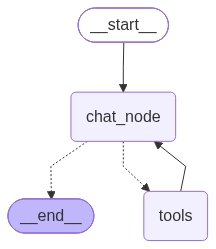

In [31]:
chatbot

In [32]:
result = chatbot.invoke(
    {'messages':
        [HumanMessage(
            content=(
            'what is consistent hashing? and which chapter is it in?'
            )
        )
    ]
}
)

In [34]:
print(result['messages'][-1].content)

Consistent Hashing is a specialized hashing technique designed to minimize the number of keys that need to be remapped when the size of the hash table (i.e., the number of servers or nodes in a distributed system) changes.

It's a crucial concept in building scalable, fault-tolerant distributed systems.

---

### What is Consistent Hashing?

To understand consistent hashing, let's first look at the problem it solves:

**The Problem with Traditional Hashing in Distributed Systems:**

Imagine you have `N` servers (e.g., cache servers, database shards) and you want to distribute `K` data items (e.g., user profiles, cached objects) among them. A common way to do this is using the modulo operator:

`server_index = hash(key) % N`

This works fine as long as `N` is constant. However, what happens when:
1.  **You add a new server (N+1):** Now you have `N+1` servers. If you recompute `hash(key) % (N+1)` for all keys, almost *all* keys will likely map to a different server. This means massive da